In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D
from scdepth.bindings import Downsampler
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import scdepth.fn as fn, scdepth.fit as fit, scdepth.pl as pl, scdepth.filt as filt
from scipy import stats

In [2]:
pref = '../visium_hd'
sample = 'Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1'
prefix = f'{pref}/{sample}/scdepth'
print(prefix)
bdf = pd.read_csv(f'{prefix}_fit_baseline.txt', sep='\t').iloc[0]
brpm = pd.read_csv(f'{prefix}_fit_rpm_histograms.txt', sep='\t')
curves = pd.read_csv(f'{prefix}_limit_curves.txt', sep='\t')

../visium_hd/Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1/scdepth


In [3]:
curves

,sample,limit,curve_0_reads,curve_0_saturation,curve_0_0_nb_lib,curve_0_1_nb_lib,curve_0_2_nb_lib,curve_0_3_nb_lib,curve_0_4_nb_lib,curve_0_5_nb_lib,...,curve_9_3_nb_lib,curve_9_4_nb_lib,curve_9_5_nb_lib,curve_9_6_nb_lib,curve_9_7_nb_lib,curve_9_8_nb_lib,curve_9_9_nb_lib,curve_9_10_nb_lib,curve_9_11_nb_lib,curve_9_12_nb_lib
0,Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1,10.0,19554869,9.992519,9.992511,9.985143,9.992317,9.991145,9.994199,9.994545,...,9.989032,9.992694,9.995438,9.998173,9.998348,9.999072,9.999733,10.001044,10.004523,10.009633
1,Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1,15.0,30626828,14.974985,14.986280,14.974989,14.986028,14.985007,14.989201,14.990102,...,14.981471,14.986906,14.990446,14.994488,14.994628,14.995334,14.995863,14.997050,15.000924,15.006612
2,Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1,20.0,42755419,19.980005,19.980293,19.964972,19.980005,19.979598,19.984676,19.986365,...,19.975242,19.982393,19.986362,19.991658,19.991688,19.992138,19.992244,19.992821,19.996244,20.001268
3,Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1,25.0,56130065,24.975759,24.975423,24.956014,24.975123,24.975761,24.981471,24.984161,...,24.968938,24.977734,24.981777,24.988263,24.988110,24.988083,24.987496,24.987008,24.989183,24.992374
4,Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1,30.0,70973287,29.974672,29.966783,29.943291,29.966494,29.968569,29.974663,29.978541,...,29.964529,29.974877,29.978657,29.986258,29.985856,29.985147,29.983622,29.981652,29.981843,29.982120
5,Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1,35.0,87627182,34.981035,34.965967,34.938459,34.965710,34.969574,34.975811,34.981036,...,34.957987,34.969775,34.972976,34.981600,34.980893,34.979320,34.976641,34.972824,34.970370,34.966766
6,Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1,40.0,106450208,39.974168,39.959605,39.928241,39.959398,39.965338,39.971487,39.978177,...,39.956538,39.969628,39.971966,39.981503,39.980443,39.977854,39.973839,39.967866,39.962196,39.953877
7,Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1,45.0,128011694,44.976864,44.955768,44.920806,44.955628,44.963864,44.969706,44.977935,...,44.955375,44.969597,44.970823,44.981145,44.979696,44.975973,44.970490,44.962127,44.952792,44.939096
8,Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1,50.0,153048620,49.971399,49.951594,49.913418,49.951536,49.962194,49.967529,49.977309,...,49.954022,49.969171,49.969085,49.980034,49.978177,49.973248,49.966222,49.955332,49.942027,49.922513
9,Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1,55.0,182658194,54.965356,54.951903,54.911044,54.951936,54.965033,54.969682,54.980955,...,54.956197,54.972022,54.970486,54.981878,54.979611,54.973461,54.964887,54.951451,54.934057,54.908547


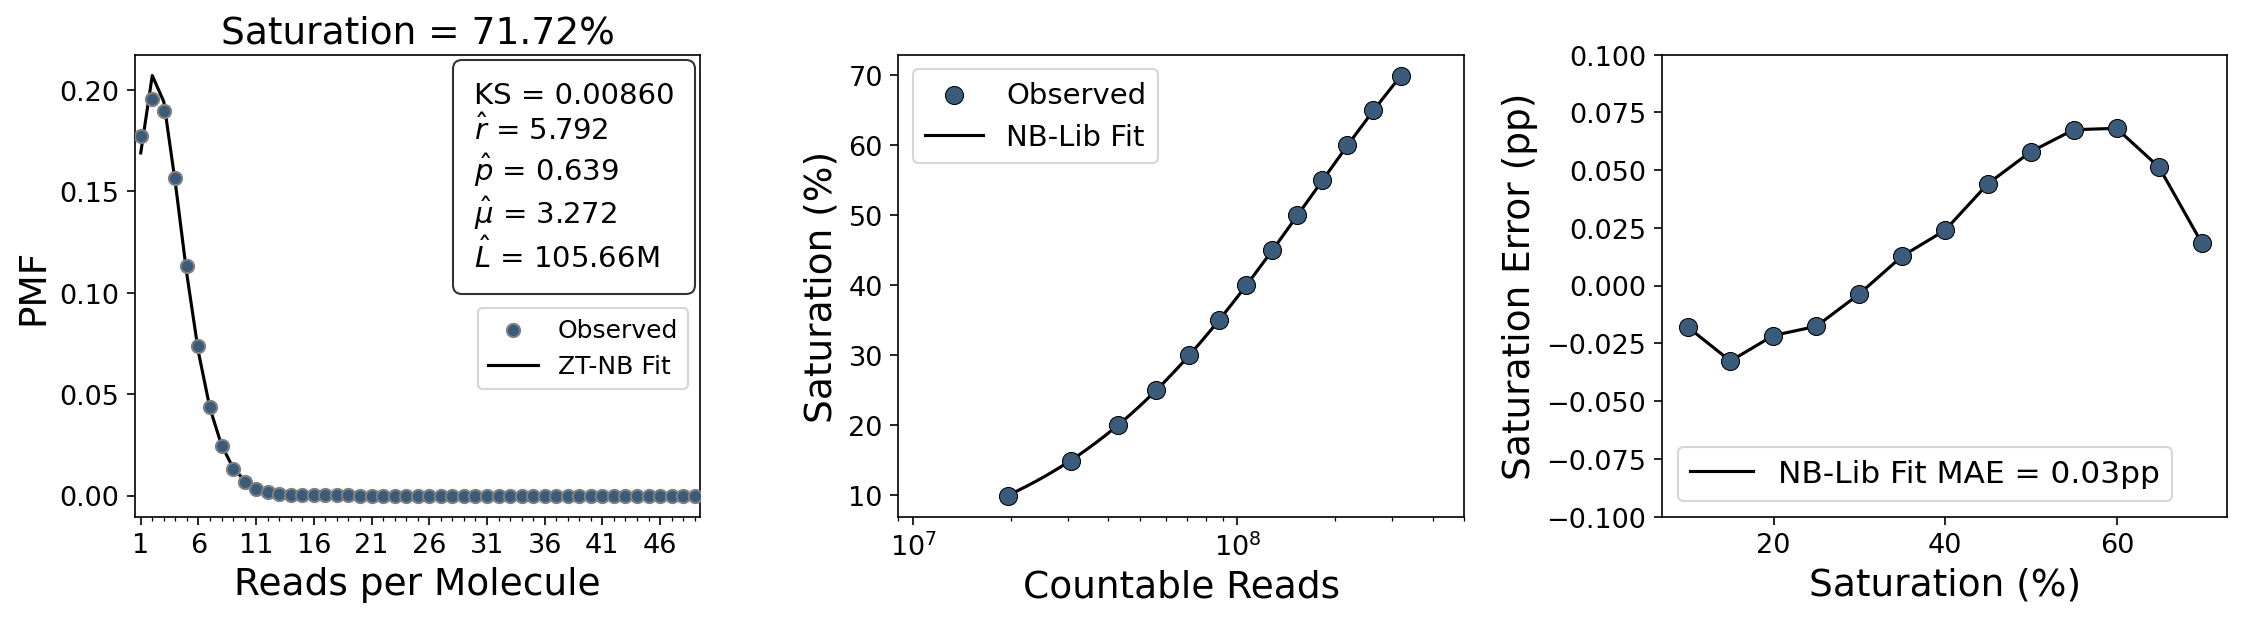

In [4]:
fig, axs = pl.figax(1, 3, w=6, h=4)
hist = brpm['full_total']
fig.subplots_adjust(wspace=0.35)
nbl = fit.NBLibFit()
nbl.fit(hist, reads=bdf.full_reads, molecules=bdf.full_molecules)
pl.fits.plot_ztnb(axs[0], nbl, hist, bdf, skip_legend = False, fs=14, s=6, lw=3)
axs[0].set_title(f'Saturation = {bdf.full_saturation:.2f}%', fontsize=18)
axs[1].scatter(curves['curve_0_reads'], curves['curve_0_saturation'], label='Observed', zorder=5, edgecolor='k', lw=0.5, s=75, color='#3b5b7a')

xp = np.linspace(curves['curve_0_reads'].min(), curves['curve_0_reads'].max(), 5000)
axs[1].plot(xp, nbl.predict_saturation(xp), color='k', label='NB-Lib Fit')
ERR = curves['curve_0_saturation'] - nbl.predict_saturation(curves['curve_0_reads'].values) 
axs[2].plot(curves['curve_0_saturation'], ERR, color='k', label=f'NB-Lib Fit MAE = {np.abs(ERR).mean():.2f}pp')
axs[2].legend(loc = 'lower left', fontsize=15)
axs[2].scatter(curves['curve_0_saturation'], ERR, zorder=5, edgecolor='k', lw=0.5, s=75, color='#3b5b7a')
axs[2].set_ylabel('Saturation Error (pp)', fontsize=18)
axs[2].set_xlabel('Saturation (%)', fontsize=18)
axs[1].set_xlabel('Countable Reads', fontsize=18)
axs[1].set_ylabel('Saturation (%)', fontsize=18)
axs[1].set_xscale('log')
axs[1].legend(loc = 'upper left', fontsize=14)
axs[1].set_xlim(0.9*10**7, 5*10**8)
for ax in axs:
    ax.tick_params(axis='both', labelsize=13)
    ax.tick_params(axis='both', which='major', length=4)

axs[2].set_ylim(-0.1, 0.1)
fig.savefig('../Figures/Figure 1ABC NB-Lib Demo.svg', bbox_inches='tight')